# LSTM model

> Link kaggle: https://www.kaggle.com/code/minhnvm2307/lstm-autoscaling-analysis

> Estimated run time: 3 min

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import joblib

# Data Preparation

In [2]:
df = pd.read_csv("/kaggle/input/auto-scaling-analysis-data/train.csv")
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d/%b/%Y:%H:%M:%S %z"
)

df = df.set_index("timestamp")

df.head()

,request_src,method,dest_path,http_type,status,bytes
timestamp,,,,,,
1995-07-01 00:00:01-04:00,199.72.81.55,GET,/history/apollo/,HTTP/1.0,200,6245
1995-07-01 00:00:06-04:00,unicomp6.unicomp.net,GET,/shuttle/countdown/,HTTP/1.0,200,3985
1995-07-01 00:00:09-04:00,199.120.110.21,GET,/shuttle/missions/sts-73/mission-sts-73.html,HTTP/1.0,200,4085
1995-07-01 00:00:11-04:00,burger.letters.com,GET,/shuttle/countdown/liftoff.html,HTTP/1.0,304,0
1995-07-01 00:00:11-04:00,199.120.110.21,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,HTTP/1.0,200,4179


In [30]:
# Define training data
chunk_time = '15min'
feature = 'bytes'

df["request_count"] = 1

# Split by 1m
df_chunk = df.resample(chunk_time).agg({
    "request_count": "sum",
    "bytes": "sum",
})

series = df_chunk[feature].values

df_chunk.head()

,request_count,bytes
timestamp,,
1995-07-01 00:00:00-04:00,810,16430564
1995-07-01 00:15:00-04:00,945,18046060
1995-07-01 00:30:00-04:00,1006,22420824
1995-07-01 00:45:00-04:00,804,24088038
1995-07-01 01:00:00-04:00,750,17178646


In [31]:
PARAMS = {
    'train_window': 10,   # Giảm window xuống để model tập trung vào pattern gần
    'predict_window': 1,
    'batch_size': 128,     # Batch nhỏ giúp thoát local minima tốt hơn
    'hidden_size': 128,
    'num_layers': 2,      # Tăng độ sâu mô hình
    'dropout': 0.2,       # Thêm dropout để tránh overfit
    'lr': 1e-3,           # Tăng LR lên
    'epochs': 70
}

In [32]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        # Input: cửa sổ [i : i+window]
        # Target: giá trị tiếp theo [i+window]
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size]
        return x, y

In [33]:
# Dùng MinMaxScaler tốt hơn cho LSTM (tanh activation)
# scaler = MinMaxScaler(feature_range=(0, 1))
scaler = StandardScaler()
series_scaled = scaler.fit_transform(series.reshape(-1, 1))
joblib.dump(scaler, 'scaler.pkl')

# Split Train/Val
train_size = int(len(series_scaled) * 0.8)
train_data = series_scaled[:train_size]
val_data = series_scaled[train_size:]

In [34]:
train_ds = TimeSeriesDataset(train_data, PARAMS['train_window'])
val_ds = TimeSeriesDataset(val_data, PARAMS['train_window'])

train_loader = DataLoader(train_ds, batch_size=PARAMS['batch_size'], shuffle=True)
# Val loader không shuffle để vẽ biểu đồ cho đúng thứ tự
val_loader = DataLoader(val_ds, batch_size=PARAMS['batch_size'], shuffle=False)

print("Training size:", len(train_data), '\nValid size:', len(val_data))

Training size: 4070 
Valid size: 1018


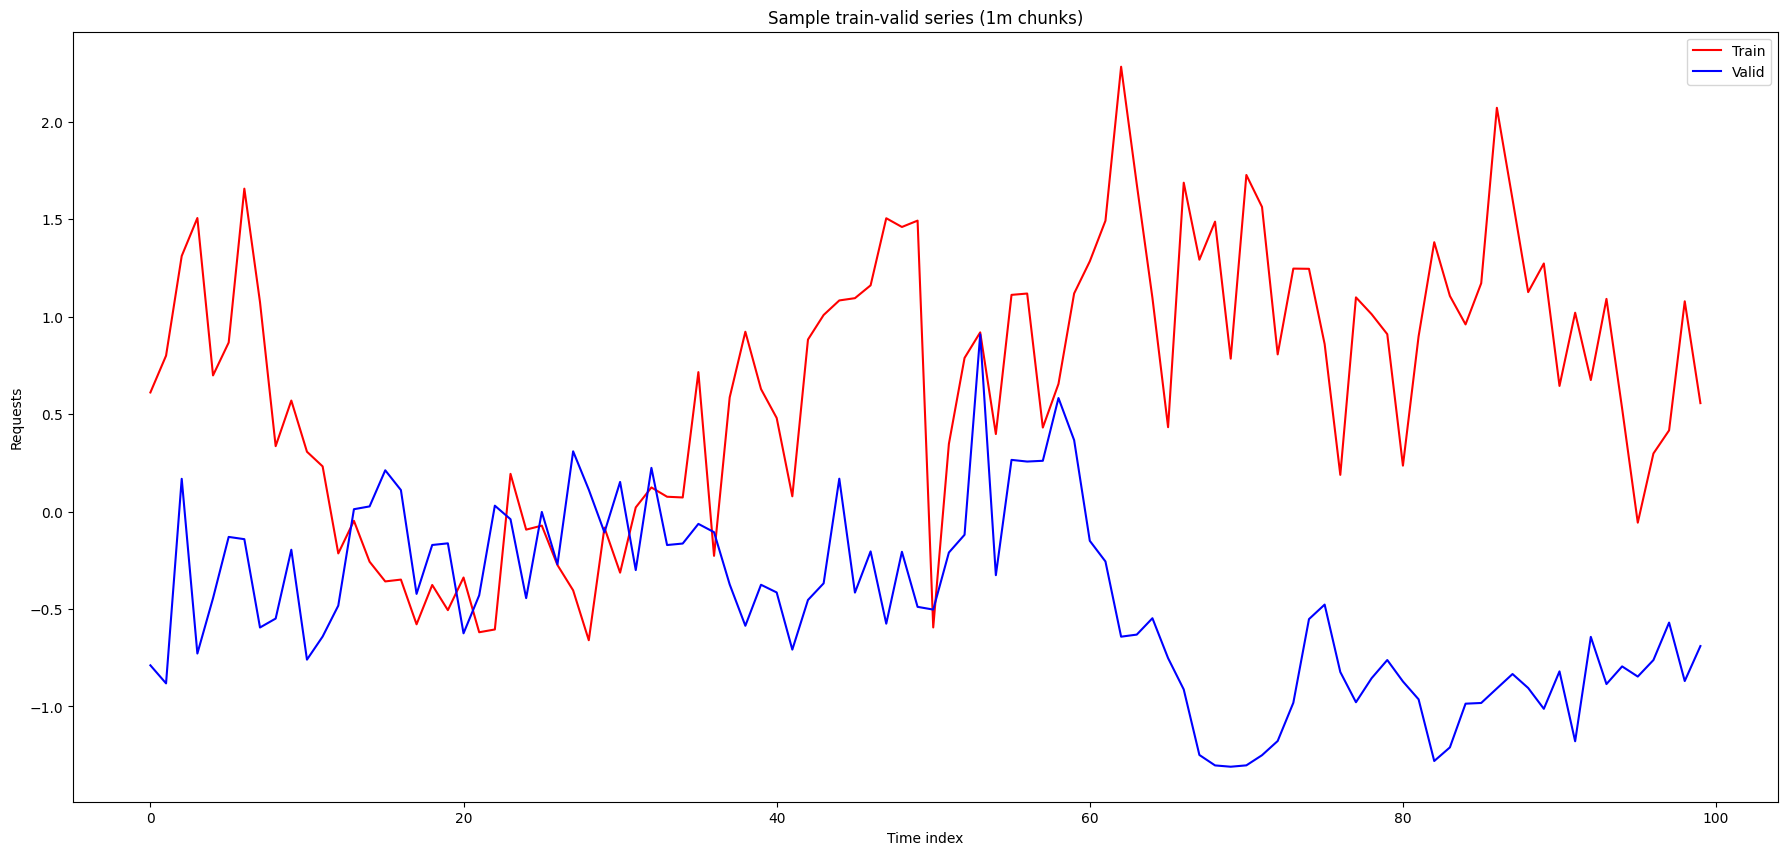

In [35]:
# Plot train-valid
sample_size = 100
plt.figure(figsize=(22,10))
plt.title("Sample train-valid series (1m chunks)")
plt.xlabel("Time index")
plt.ylabel("Requests")
plt.plot(train_data[:sample_size], color='red', label='Train')
plt.plot(val_data[:sample_size], color='blue', label='Valid')
plt.legend()
plt.show()

In [36]:
for i in train_loader:
  print("Input shape:", i[0].shape, "\nOutput shape:", i[1].shape)
  break;

Input shape: torch.Size([128, 10, 1]) 
Output shape: torch.Size([128, 1])


# LSTM Model training

In [37]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.lstm(x)

        last_out = out[:, -1, :] 
        prediction = self.fc(last_out)
        return prediction

### SMAPE Loss

In [38]:
class SMAPELoss(nn.Module):
    def __init__(self, epsilon=0.1):
        super(SMAPELoss, self).__init__()
        self.epsilon = epsilon

    def forward(self, pred, target):
        """
        Tính toán Smooth SMAPE để có thể backprop được.
        Công thức gốc: 2 * |y_pred - y_true| / (|y_pred| + |y_true|)
        Công thức smooth: tránh chia cho 0 bằng cách thêm epsilon vào mẫu số.
        """
        pred = pred.view_as(target)
        
        diff = torch.abs(pred - target)
        # max(sum, 0.5 + epsilon) để chặn dưới
        denominator = torch.abs(pred) + torch.abs(target) + self.epsilon
        smape = 2.0 * diff / denominator
        
        return torch.mean(smape)

criterion = SMAPELoss(epsilon=0.1)

# Ví dụ test
y_pred = torch.tensor([100.0, 0.0, 10.0], requires_grad=True)
y_true = torch.tensor([110.0, 0.0, 10.0])

loss = criterion(y_pred, y_true)
loss.backward() 
print("Test Loss:", loss.item())

Test Loss: 0.03173092007637024


In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(
    input_size=1,
    hidden_size=PARAMS['hidden_size'],
    num_layers=PARAMS['num_layers'],
    output_size=1,
    dropout=PARAMS['dropout']
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=PARAMS['lr'])

### Training phase

In [40]:
best_loss = float('inf')
history = {'train': [], 'val': []}

print(f"Training on {device}...")

for epoch in range(PARAMS['epochs']):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm.pth')
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Training on cuda...
Epoch 05 | Train Loss: 0.309022 | Val Loss: 0.277111
Epoch 10 | Train Loss: 0.298310 | Val Loss: 0.276582
Epoch 15 | Train Loss: 0.290711 | Val Loss: 0.271481
Epoch 20 | Train Loss: 0.290650 | Val Loss: 0.273183
Epoch 25 | Train Loss: 0.292909 | Val Loss: 0.271214
Epoch 30 | Train Loss: 0.290041 | Val Loss: 0.271122
Epoch 35 | Train Loss: 0.288991 | Val Loss: 0.270921
Epoch 40 | Train Loss: 0.289296 | Val Loss: 0.271088
Epoch 45 | Train Loss: 0.291558 | Val Loss: 0.271092
Epoch 50 | Train Loss: 0.288100 | Val Loss: 0.271049
Epoch 55 | Train Loss: 0.287923 | Val Loss: 0.271240
Epoch 60 | Train Loss: 0.288867 | Val Loss: 0.269715
Epoch 65 | Train Loss: 0.287509 | Val Loss: 0.272678
Epoch 70 | Train Loss: 0.288674 | Val Loss: 0.273291


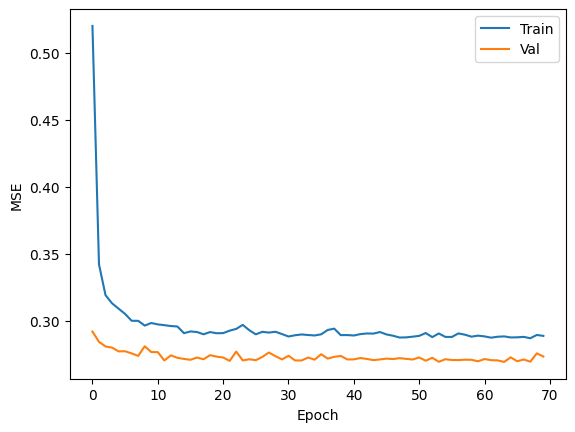

In [41]:
plt.plot(history["train"], label="Train")
plt.plot(history["val"], label="Val")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

### Evaluation phase

In [42]:
model.load_state_dict(torch.load('best_lstm.pth', map_location=device))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(device)
        pred = model(x_batch)
        # Đưa về CPU numpy
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

# Gộp các batch lại
predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# Inverse transform để về giá trị request thật
predictions_inv = scaler.inverse_transform(predictions)
actuals_inv = scaler.inverse_transform(actuals)

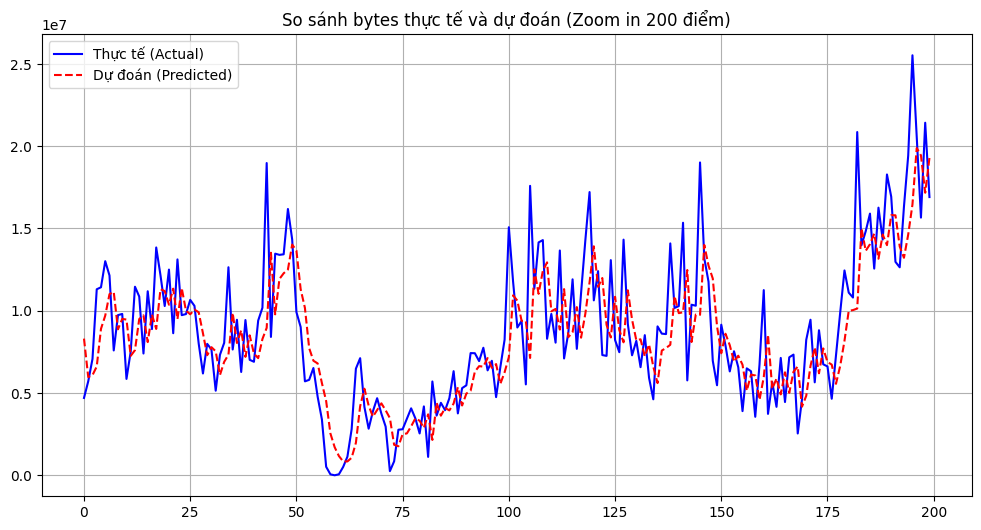

In [43]:
limit = 200 

plt.figure(figsize=(12, 6))
plt.plot(actuals_inv[:limit], label='Thực tế (Actual)', color='blue')
plt.plot(predictions_inv[:limit], label='Dự đoán (Predicted)', color='red', linestyle='--')
plt.title(f"So sánh {feature} thực tế và dự đoán (Zoom in 200 điểm)")
plt.legend()
plt.grid(True)
plt.show()

# Evaluate on test data

In [44]:
test_df = pd.read_csv('/kaggle/input/auto-scaling-analysis-data/test.csv')

test_df["timestamp"] = pd.to_datetime(
    test_df["timestamp"],
    format="%d/%b/%Y:%H:%M:%S %z"
)

test_df = test_df.set_index("timestamp")
test_df["request_count"] = 1
test_df = test_df.resample(chunk_time).agg({
    "request_count": "sum",
    "bytes": "sum",
})
test_df.head()

,request_count,bytes
timestamp,,
1995-08-23 00:00:00-04:00,443,8924017
1995-08-23 00:15:00-04:00,413,7176447
1995-08-23 00:30:00-04:00,313,5208197
1995-08-23 00:45:00-04:00,334,7282676
1995-08-23 01:00:00-04:00,190,3863356


In [45]:
df_chunk.tail(PARAMS['train_window'])

,request_count,bytes
timestamp,,
1995-08-22 21:30:00-04:00,534,9939361
1995-08-22 21:45:00-04:00,567,8952425
1995-08-22 22:00:00-04:00,516,8432048
1995-08-22 22:15:00-04:00,488,7188371
1995-08-22 22:30:00-04:00,398,8205668
1995-08-22 22:45:00-04:00,435,7308498
1995-08-22 23:00:00-04:00,510,5480335
1995-08-22 23:15:00-04:00,393,6420996
1995-08-22 23:30:00-04:00,336,6792788


In [46]:
# Scale
padding_data = df_chunk.tail(PARAMS['train_window'])
full_test_series = pd.concat([padding_data, test_df], axis=0).reset_index(drop=True)
test_data = full_test_series[feature].values.reshape(-1, 1)
test_series_scaled = scaler.transform(test_data)
print("Test shape:", len(test_data))

Test shape: 874


In [47]:
test_ds = TimeSeriesDataset(test_series_scaled, PARAMS['train_window'])
test_loader = DataLoader(test_ds, batch_size=PARAMS['batch_size'], shuffle=False)

# model
model.load_state_dict(torch.load('best_lstm.pth', map_location=device))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        pred = model(x_batch)

        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

# Gộp các batch lại
predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# Inverse transform để về giá trị request thật
predictions_inv = scaler.inverse_transform(predictions)
actuals_inv = scaler.inverse_transform(actuals)

### Metrics evaluation

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(actuals_inv, predictions_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals_inv, predictions_inv)

# MAPE (Mean Absolute Percentage Error)
# Cho biết model sai lệch bao nhiêu % so với thực tế.
def calculate_mape(y_true, y_pred):
    # MAPE
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # SMAPE
    epsilon = 0.1
    summ = np.maximum(np.abs(y_true) + np.abs(y_pred) + epsilon, 0.5 + epsilon)
    smape = np.mean((np.abs(y_pred - y_true) / summ) * 2.0) * 100
    return mape, smape

mape, smape = calculate_mape(actuals_inv, predictions_inv)

# R2 Score (Coefficient of Determination)
# Đo độ phù hợp của mô hình (càng gần 1 càng tốt, âm là model tệ hơn đoán bừa)
r2 = r2_score(actuals_inv, predictions_inv)

print("-" * 30)
print(f"Evaluation Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")
print(f"R2   : {r2:.4f}")
print("-" * 30)

------------------------------
Evaluation Metrics:
MSE  : 8516757094400.0000
RMSE : 2918348.3504
MAE  : 2163102.7500
MAPE : 26.37%
SMAPE: 24.57%
R2   : 0.7377
------------------------------


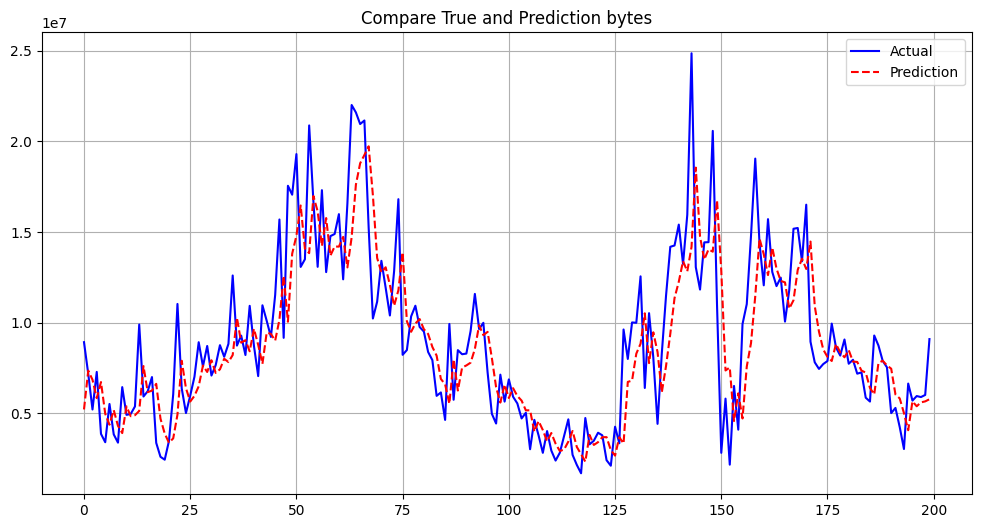

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(actuals_inv[:200], label='Actual', color='blue')
plt.plot(predictions_inv[:200], label='Prediction', color='red', linestyle='--')
plt.title(f"Compare True and Prediction {feature}")
plt.legend()
plt.grid(True)
plt.show()

## Spike detection

In [50]:
from scipy.signal import find_peaks

class EventEvaluator:
    def __init__(self, tolerance=1):
        """
        tolerance: Số bước thời gian cho phép sai lệch.
                   Ví dụ tolerance=2 nghĩa là đỉnh dự đoán lệch sớm/muộn 2 nhịp 
                   so với đỉnh thật vẫn được tính là đúng (True Positive).
        """
        self.tolerance = tolerance

    def _match_events(self, true_indices, pred_indices):
        """
        Hàm cốt lõi để ghép cặp sự kiện giữa thực tế và dự đoán 
        dựa trên khoảng cách thời gian gần nhất.
        """
        tp = 0  # True Positives
        matched_pred = set()
        matched_true = set()
        
        # Tạo danh sách các cặp ứng viên có thể match (khoảng cách <= tolerance)
        candidates = []
        for t_idx in true_indices:
            for p_idx in pred_indices:
                dist = abs(t_idx - p_idx)
                if dist <= self.tolerance:
                    candidates.append((dist, t_idx, p_idx))
        
        # Sắp xếp ưu tiên các cặp gần nhau nhất trước
        candidates.sort(key=lambda x: x[0])
        
        # Duyệt và ghép cặp (Greedy matching)
        for _, t_idx, p_idx in candidates:
            if t_idx not in matched_true and p_idx not in matched_pred:
                matched_true.add(t_idx)
                matched_pred.add(p_idx)
                tp += 1
                
        fn = len(true_indices) - len(matched_true) # Có thật mà không đoán được
        fp = len(pred_indices) - len(matched_pred) # Đoán mà không có thật
        
        return tp, fp, fn

    def _calculate_metrics(self, tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        return {
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "TP": tp, "FP": fp, "FN": fn
        }

    def evaluate_spikes(self, y_true, y_pred, threshold_std=3):
        """
        Đánh giá Spikes (các điểm đột biến vượt quá giới hạn Z-score).
        Spike được định nghĩa là giá trị > mean + k*std
        """
        # Tính ngưỡng dựa trên dữ liệu thật
        mean = np.mean(y_true)
        std = np.std(y_true)
        limit = mean + threshold_std * std
        
        true_spikes = np.where(y_true > limit)[0]
        pred_spikes = np.where(y_pred > limit)[0]
        
        tp, fp, fn = self._match_events(true_spikes, pred_spikes)
        return self._calculate_metrics(tp, fp, fn)

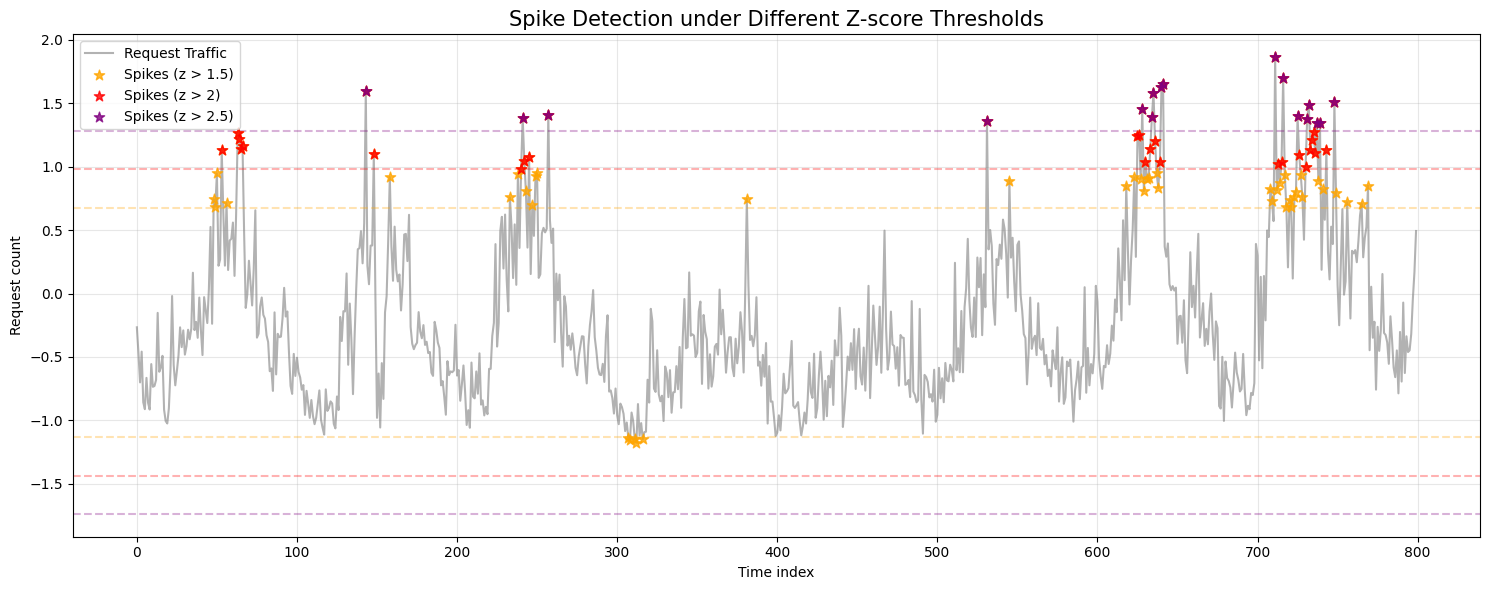

In [51]:
y = actuals[:800, 0]
x = np.arange(len(y))

mean = np.mean(y)
std = np.std(y)

thresholds = [1.5, 2, 2.5]
colors = ['orange', 'red', 'purple']

plt.figure(figsize=(15, 6))
plt.plot(x, y, label='Request Traffic', color='gray', alpha=0.6)

for thres, color in zip(thresholds, colors):
    spikes = np.where(np.abs(y - mean) > thres * std)[0]

    plt.scatter(
        x[spikes],
        y[spikes],
        s=60,
        marker='*',
        color=color,
        alpha=0.8,
        label=f'Spikes (z > {thres})',
        zorder=4
    )

    # Vẽ ngưỡng
    plt.axhline(mean + thres * std, color=color, linestyle='--', alpha=0.3)
    plt.axhline(mean - thres * std, color=color, linestyle='--', alpha=0.3)

plt.title("Spike Detection under Different Z-score Thresholds", fontsize=15)
plt.xlabel("Time index")
plt.ylabel("Request count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
from pprint import pprint

evaluator = EventEvaluator(tolerance=2)

spike_results = {}

for thres in thresholds:
    metrics = evaluator.evaluate_spikes(
        actuals_inv.flatten(),
        predictions_inv.flatten(),
        threshold_std=thres
    )
    spike_results[f"z>{thres}"] = metrics

print("\n--- SPIKE DETECTION BY Z-SCORE ---")
pprint(spike_results)


--- SPIKE DETECTION BY Z-SCORE ---
{'z>1.5': {'F1-Score': 0.7532467532467532,
           'FN': 28,
           'FP': 10,
           'Precision': 0.8529411764705882,
           'Recall': 0.6744186046511628,
           'TP': 58},
 'z>2': {'F1-Score': 0.6285714285714286,
         'FN': 25,
         'FP': 1,
         'Precision': 0.9565217391304348,
         'Recall': 0.46808510638297873,
         'TP': 22},
 'z>2.5': {'F1-Score': 0.2727272727272727,
           'FN': 16,
           'FP': 0,
           'Precision': 1.0,
           'Recall': 0.15789473684210525,
           'TP': 3}}


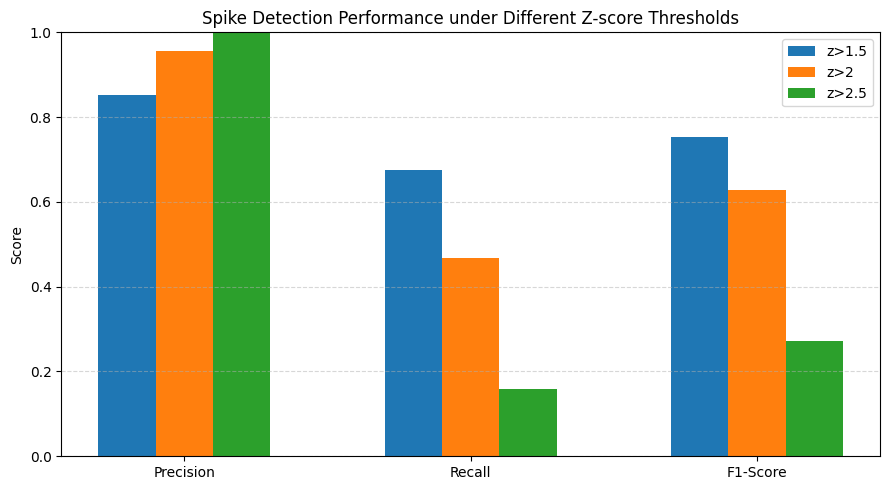

In [53]:
metric_names = ["Precision", "Recall", "F1-Score"]

x = np.arange(len(metric_names))
width = 0.2

plt.figure(figsize=(9,5))

for i, (label, vals) in enumerate(spike_results.items()):
    scores = [vals[m] for m in metric_names]
    plt.bar(x + i * width, scores, width, label=label)

plt.xticks(x + width, metric_names)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Spike Detection Performance under Different Z-score Thresholds")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## *Rolling Forecast Eval

In [54]:
def rolling_predict(model, test_np, scaler, device, forecast_steps):
    model.eval()
    
    scaled_data = test_np
    
    preds_scaled = []
    lookback = PARAMS['train_window'] 
    
    num_samples = len(scaled_data) - lookback - forecast_steps
    with torch.no_grad():
        for start_idx in range(0, num_samples, forecast_steps):
            
            # Khởi tạo window
            current_window = scaled_data[start_idx : start_idx + lookback].copy()
            current_window_tensor = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(device)
            
            # Dự báo cuốn chiếu forecast_steps bước
            for _ in range(forecast_steps):
                # Forward pass: (1, lookback, 1) -> (1, 1)
                prediction = model(current_window_tensor)
                
                pred_val = prediction.cpu().numpy().flatten()[0]
                preds_scaled.append(pred_val)
                
                # --- ROLLING LOGIC ---
                pred_tensor = torch.tensor([[[pred_val]]], dtype=torch.float32).to(device)
                current_window_tensor = torch.cat([current_window_tensor[:, 1:, :], pred_tensor], dim=1)
        
    preds_scaled_array = np.array(preds_scaled).reshape(-1, 1)
    final_preds = scaler.inverse_transform(preds_scaled_array)
    targets_raw = test_np[lookback : lookback + len(final_preds)]
    targets_raw = scaler.inverse_transform(targets_raw)
    
    return final_preds, targets_raw

predictions_inv, actuals_inv = rolling_predict(model=model, test_np=test_series_scaled, scaler=scaler, device=device, forecast_steps=30)

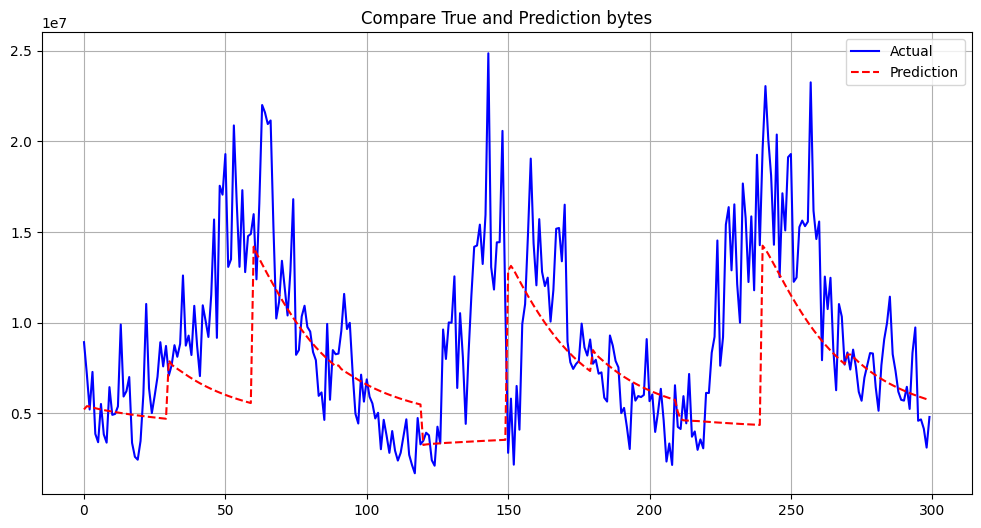

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(actuals_inv[:300], label='Actual', color='blue')
plt.plot(predictions_inv[:300], label='Prediction', color='red', linestyle='--')
plt.title(f"Compare True and Prediction {feature}")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(actuals_inv, predictions_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals_inv, predictions_inv)

# MAPE (Mean Absolute Percentage Error)
# Cho biết model sai lệch bao nhiêu % so với thực tế.
def calculate_mape(y_true, y_pred):
    # MAPE
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # SMAPE
    epsilon = 0.1
    summ = np.maximum(np.abs(y_true) + np.abs(y_pred) + epsilon, 0.5 + epsilon)
    smape = np.mean((np.abs(y_pred - y_true) / summ) * 2.0) * 100
    return mape, smape

mape, smape = calculate_mape(actuals_inv, predictions_inv)

# R2 Score (Coefficient of Determination)
# Đo độ phù hợp của mô hình (càng gần 1 càng tốt, âm là model tệ hơn đoán bừa)
r2 = r2_score(actuals_inv, predictions_inv)

print("-" * 30)
print(f"Evaluation Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")
print(f"R2   : {r2:.4f}")
print("-" * 30)

------------------------------
Evaluation Metrics:
MSE  : 27900389687979.5898
RMSE : 5282081.9464
MAE  : 3676751.1012
MAPE : 40.20%
SMAPE: 41.94%
R2   : 0.1553
------------------------------
